In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Creación de carpetas
os.makedirs('data/raw', exist_ok=True)
os.makedirs('dashboard', exist_ok=True)

# Crear el archivo CSV con datos de prueba
datos = """transaction_id,date,category,channel,units_sold,unit_price,total_revenue,cost
1001,2023-01-15,Electrónica,Online,2,150.0,300.0,200.0
1002,2023-01-16,Ropa,Tienda,1,50.0,50.0,25.0
1003,2023-01-18,Hogar,Online,3,80.0,,180.0
1004,2023-02-01,Electrónica,Tienda,1,1200.0,1200.0,900.0
1005,2023-02-10,Ropa,Online,4,30.0,120.0,60.0
1006,2023-02-10,Ropa,Online,4,30.0,120.0,60.0"""

with open('data/raw/retail_sales.csv', 'w', encoding='utf-8') as f:
  f.write(datos)

print("¡Archivo retail_sales.csv creado con éxito!")

¡Archivo retail_sales.csv creado con éxito!


In [2]:
# Cargar el dataset
df = pd.read_csv('data/raw/retail_sales.csv')

# 1. Eliminar filas duplicadas
df = df.drop_duplicates()

# 2. Convertir la columna fecha a formato datetime
df['date'] = pd.to_datetime(df['date'])

# 3. Imputar valores nulos en total_revenue (units_sold * unit_price)
df['total_revenue'] = df['total_revenue'].fillna(
    df['units_sold'] * df['unit_price']
)

# 4. Crear columna de ganancia (profit)
df['profit'] = df['total_revenue'] - df['cost']

print("--- Datos limpios ---")
display(df)

--- Datos limpios ---


,transaction_id,date,category,channel,units_sold,unit_price,total_revenue,cost,profit
0,1001,2023-01-15,Electrónica,Online,2,150.0,300.0,200.0,100.0
1,1002,2023-01-16,Ropa,Tienda,1,50.0,50.0,25.0,25.0
2,1003,2023-01-18,Hogar,Online,3,80.0,240.0,180.0,60.0
3,1004,2023-02-01,Electrónica,Tienda,1,1200.0,1200.0,900.0,300.0
4,1005,2023-02-10,Ropa,Online,4,30.0,120.0,60.0,60.0
5,1006,2023-02-10,Ropa,Online,4,30.0,120.0,60.0,60.0


/tmp/ipykernel_2308/2676892577.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_2308/2676892577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


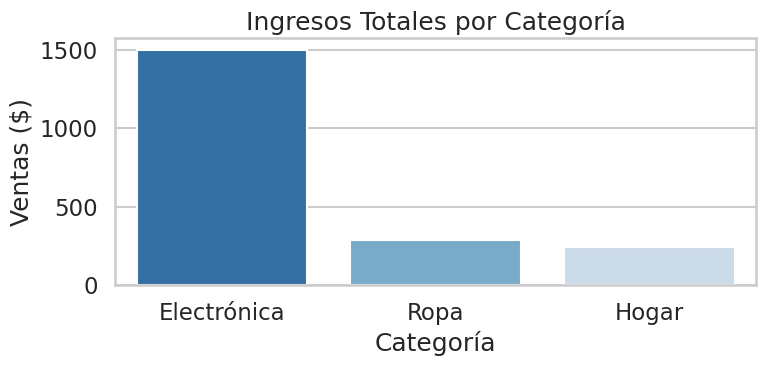

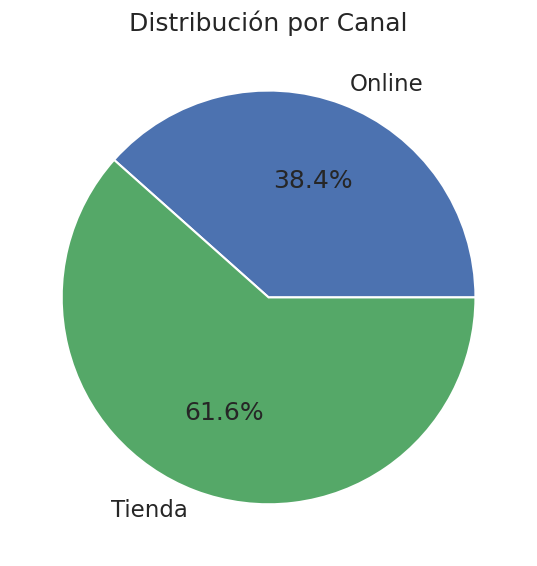

In [3]:
# Configuración visual
sns.set_theme(style='whitegrid', context='talk')

# Gráfico 1: Ventas por Categoría
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df,
    x='category',
    y='total_revenue',
    estimator=sum,
    ci=None,
    palette='Blues_r',
)
plt.title('Ingresos Totales por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas ($)')
plt.tight_layout()
plt.savefig('dashboard/ventas_por_categoria.png', dpi=300)
plt.show()

# Gráfico 2: Ventas por Canal
plt.figure(figsize=(6, 6))
ventas_canal = df.groupby('channel')['total_revenue'].sum()
plt.pie(
    ventas_canal,
    labels=ventas_canal.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#55A868'],
)
plt.title('Distribución por Canal')
plt.tight_layout()
plt.savefig('dashboard/ventas_por_canal.png', dpi=300)
plt.show()